In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import brentq
from scipy.stats import norm

from src.models.black_scholes import BlackScholes
from src.models.heston import Heston
from src.engine.monte_carlo import generate_gbm_paths, price_european_mc

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

Cloning into 'option-pricing-models'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 138 (delta 64), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (138/138), 298.62 KiB | 9.95 MiB/s, done.
Resolving deltas: 100% (64/64), done.
Setup complete!


In [2]:
S0 = 100
r = 0.05
T = 1.0

strikes = np.arange(70, 131, 5)
n_paths = 100000
n_steps = 252
np.random.seed(42)

print(f"Strikes: {strikes}")
print(f"Number of paths: {n_paths}")

Strikes: [ 70  75  80  85  90  95 100 105 110 115 120 125 130]
Number of paths: 100000


In [3]:
def implied_volatility(price, S0, K, T, r, option_type):
    try:
        def f(sigma):
            bs = BlackScholes(S0, K, T, r, sigma)
            return bs.price(option_type) - price

        return brentq(f, 0.001, 5.0)
    except (ValueError, RuntimeError):
        return np.nan

In [4]:
v0 = 0.04
kappa = 2.0
theta = 0.04
sigma_v = 0.3
rho = -0.7

heston = Heston(S0, v0, kappa, theta, sigma_v, rho)
paths_heston, _ = heston.generate_paths(T, n_steps, n_paths, r, seed=42)

heston_prices = []
for K in strikes:
    price, _ = price_european_mc(paths_heston, K, r, T, 'call')
    heston_prices.append(price)

print("Heston prices computed.")

Heston prices computed.


Strike 70: price=33.8340, IV=0.2474
Strike 75: price=29.3657, IV=0.2384
Strike 80: price=25.0473, IV=0.2298
Strike 85: price=20.9343, IV=0.2217
Strike 90: price=17.0828, IV=0.2138
Strike 95: price=13.5502, IV=0.2061
Strike 100: price=10.4025, IV=0.1987
Strike 105: price=7.6847, IV=0.1915
Strike 110: price=5.4286, IV=0.1845
Strike 115: price=3.6514, IV=0.1780
Strike 120: price=2.3287, IV=0.1721
Strike 125: price=1.4023, IV=0.1667
Strike 130: price=0.7971, IV=0.1619


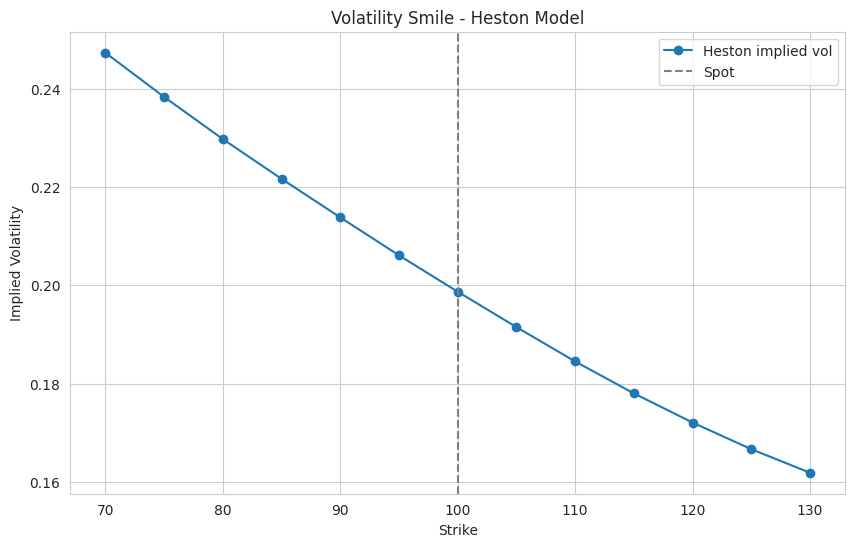

In [5]:
implied_vols = []
for K, price in zip(strikes, heston_prices):
    iv = implied_volatility(price, S0, K, T, r, 'call')
    implied_vols.append(iv)
    print(f"Strike {K}: price={price:.4f}, IV={iv:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(strikes, implied_vols, 'o-', label='Heston implied vol')
plt.axvline(x=S0, color='gray', linestyle='--', label='Spot')
plt.xlabel('Strike')
plt.ylabel('Implied Volatility')
plt.title('Volatility Smile - Heston Model')
plt.legend()
plt.grid(True)
plt.show()

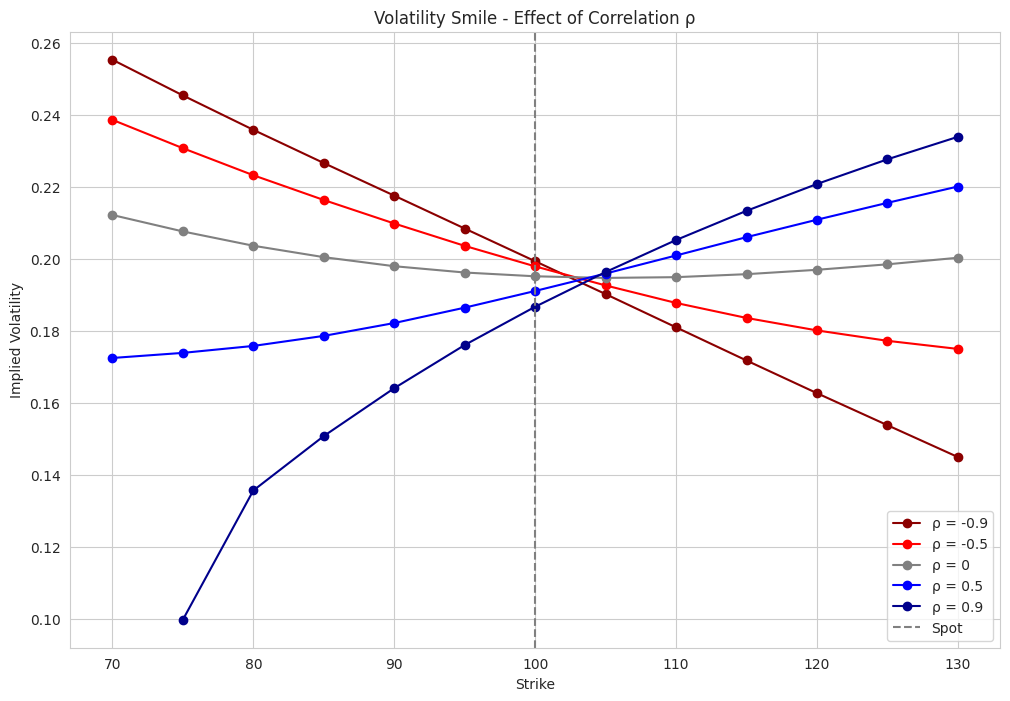

In [6]:
rhos = [-0.9, -0.5, 0, 0.5, 0.9]
colors = ['darkred', 'red', 'gray', 'blue', 'darkblue']

plt.figure(figsize=(12, 8))

for rho_val, color in zip(rhos, colors):
    heston_rho = Heston(S0, v0, kappa, theta, sigma_v, rho_val)
    paths_rho, _ = heston_rho.generate_paths(T, n_steps, n_paths, r, seed=42)

    prices_rho = []
    for K in strikes:
        p, _ = price_european_mc(paths_rho, K, r, T, 'call')
        prices_rho.append(p)

    ivs_rho = []
    for K, p in zip(strikes, prices_rho):
        ivs_rho.append(implied_volatility(p, S0, K, T, r, 'call'))

    plt.plot(strikes, ivs_rho, 'o-', color=color, label=f'ρ = {rho_val}')

plt.axvline(x=S0, color='gray', linestyle='--', label='Spot')
plt.xlabel('Strike')
plt.ylabel('Implied Volatility')
plt.title('Volatility Smile - Effect of Correlation ρ')
plt.legend()
plt.grid(True)
plt.show()

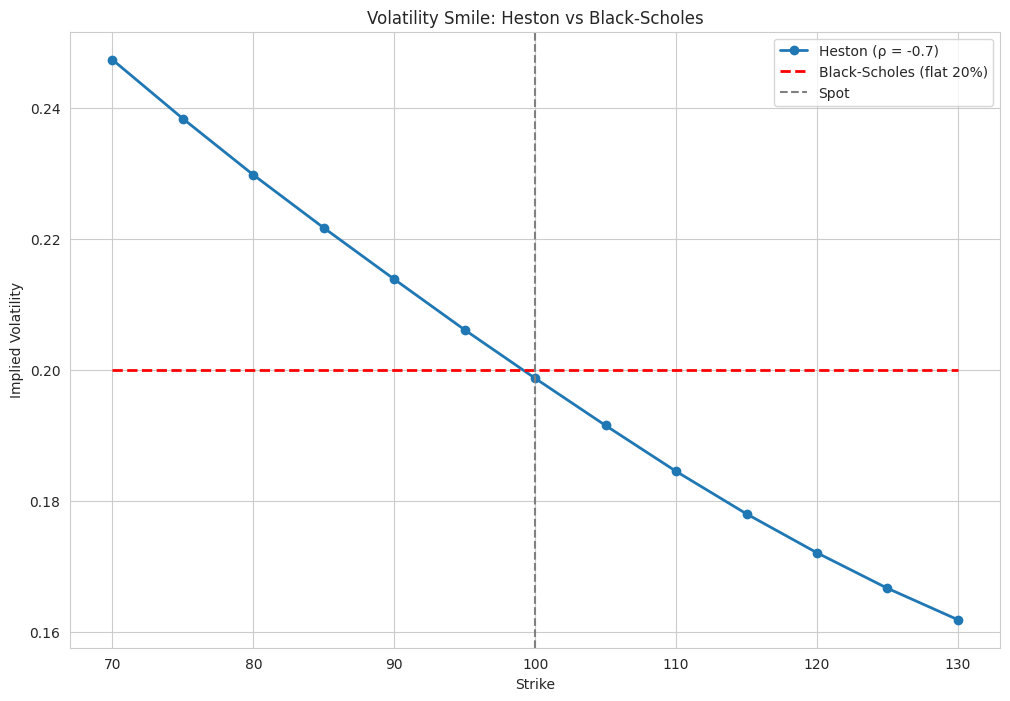

In [7]:
bs_prices = [BlackScholes(S0, K, T, r, 0.20).price('call') for K in strikes]
bs_ivs = [0.20 for _ in strikes]

plt.figure(figsize=(12, 8))
plt.plot(strikes, implied_vols, 'o-', label='Heston (ρ = -0.7)', linewidth=2)
plt.plot(strikes, bs_ivs, 'r--', label='Black-Scholes (flat 20%)', linewidth=2)
plt.axvline(x=S0, color='gray', linestyle='--', label='Spot')
plt.xlabel('Strike')
plt.ylabel('Implied Volatility')
plt.title('Volatility Smile: Heston vs Black-Scholes')
plt.legend()
plt.grid(True)
plt.show()

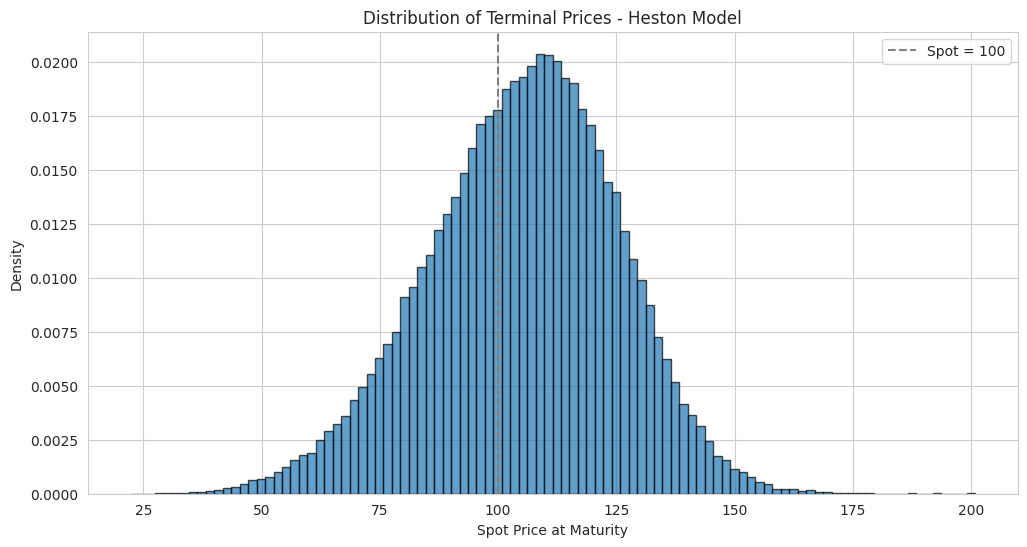

Mean: 105.1396
Std: 20.0512
Skewness: -0.2115


In [8]:
plt.figure(figsize=(12, 6))

S_T = paths_heston[:, -1]
plt.hist(S_T, bins=100, density=True, alpha=0.7, edgecolor='black')
plt.axvline(x=S0, color='gray', linestyle='--', label=f'Spot = {S0}')
plt.xlabel('Spot Price at Maturity')
plt.ylabel('Density')
plt.title('Distribution of Terminal Prices - Heston Model')
plt.legend()
plt.grid(True)
plt.show()

print(f"Mean: {np.mean(S_T):.4f}")
print(f"Std: {np.std(S_T):.4f}")
print(f"Skewness: {np.mean((S_T - np.mean(S_T))**3) / np.std(S_T)**3:.4f}")